In [4]:
import pandas as pd
df=pd.read_csv("dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48587 entries, 0 to 48586
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  48587 non-null  int64  
 1   subject     43288 non-null  object 
 2   body        48585 non-null  object 
 3   answer      48576 non-null  object 
 4   type        48587 non-null  object 
 5   queue       48587 non-null  object 
 6   priority    48587 non-null  object 
 7   language    48587 non-null  object 
 8   version     28587 non-null  float64
 9   tag_1       48587 non-null  object 
 10  tag_2       48528 non-null  object 
 11  tag_3       48356 non-null  object 
 12  tag_4       43990 non-null  object 
 13  tag_5       27636 non-null  object 
 14  tag_6       13225 non-null  object 
 15  tag_7       5968 non-null   object 
 16  tag_8       2472 non-null   object 
dtypes: float64(1), int64(1), object(15)
memory usage: 6.3+ MB


In [6]:
df.head(5)

,Unnamed: 0,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

Unnamed: 0        0
subject        5299
body              2
answer           11
type              0
queue             0
priority          0
language          0
version       20000
tag_1             0
tag_2            59
tag_3           231
tag_4          4597
tag_5         20951
tag_6         35362
tag_7         42619
tag_8         46115
dtype: int64

In [19]:
df2=df[df['language']=='en'].reset_index(drop=True)
df2 = df2[['subject', 'body', 'type', 'priority', 'queue']]
df2

,subject,body,type,priority,queue
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Incident,high,Technical Support
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Request,medium,Returns and Exchanges
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Request,low,Billing and Payments
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Problem,medium,Sales and Pre-Sales
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Request,high,Technical Support
...,...,...,...,...,...
28256,Guidelines for Securing Medical Data in OBS St...,Seeking details on securing medical data using...,Request,high,Technical Support
28257,NaN,Can you provide information on digital strateg...,Request,medium,Billing and Payments
28258,Support for Marketing Enhancements,Request for assistance in improving digital ma...,Change,high,Technical Support
28259,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,Problem,low,Technical Support


In [27]:
# df2['combined_text'] = df2['subject'].fillna('') + " " + df2['body'].fillna('')
df2=df2[['combined_text', 'type', 'priority', 'queue']]
df2.head(5)

,combined_text,type,priority,queue
0,"Account Disruption Dear Customer Support Team,...",Incident,high,Technical Support
1,Query About Smart Home System Integration Feat...,Request,medium,Returns and Exchanges
2,Inquiry Regarding Invoice Details Dear Custome...,Request,low,Billing and Payments
3,Question About Marketing Agency Software Compa...,Problem,medium,Sales and Pre-Sales
4,"Feature Query Dear Customer Support,\n\nI hope...",Request,high,Technical Support


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28261 entries, 0 to 28260
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   combined_text  28261 non-null  object
 1   type           28261 non-null  object
 2   priority       28261 non-null  object
 3   queue          28261 non-null  object
dtypes: object(4)
memory usage: 883.3+ KB


In [29]:
df2.isnull().sum()

combined_text    0
type             0
priority         0
queue            0
dtype: int64

In [30]:
df2.shape

(28261, 4)

In [31]:
import re, string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english')) - {'no', 'not', 'cannot'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df2['cleaned_text'] = df2['combined_text'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rguktrkvalley/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
df2.head(5)

,combined_text,type,priority,queue,cleaned_text
0,"Account Disruption Dear Customer Support Team,...",Incident,high,Technical Support,account disruption dear customer support teamn...
1,Query About Smart Home System Integration Feat...,Request,medium,Returns and Exchanges,query smart home system integration features d...
2,Inquiry Regarding Invoice Details Dear Custome...,Request,low,Billing and Payments,inquiry regarding invoice details dear custome...
3,Question About Marketing Agency Software Compa...,Problem,medium,Sales and Pre-Sales,question marketing agency software compatibili...
4,"Feature Query Dear Customer Support,\n\nI hope...",Request,high,Technical Support,feature query dear customer supportnni hope me...


In [36]:
df3=df2[['cleaned_text','type','priority','queue']]
df3

,cleaned_text,type,priority,queue
0,account disruption dear customer support teamn...,Incident,high,Technical Support
1,query smart home system integration features d...,Request,medium,Returns and Exchanges
2,inquiry regarding invoice details dear custome...,Request,low,Billing and Payments
3,question marketing agency software compatibili...,Problem,medium,Sales and Pre-Sales
4,feature query dear customer supportnni hope me...,Request,high,Technical Support
...,...,...,...,...
28256,guidelines securing medical data obs studio se...,Request,high,Technical Support
28257,provide information digital strategies boost b...,Request,medium,Billing and Payments
28258,support marketing enhancements request assista...,Change,high,Technical Support
28259,assistance needed ifttt docker integration fac...,Problem,low,Technical Support


In [37]:
df3.to_csv("cleaned_customer_support_english.csv", index=False)
print("Cleaned dataset saved:", df3.shape)


Cleaned dataset saved: (28261, 4)


/tmp/ipykernel_70360/869321432.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df3, x='type', order=df3['type'].value_counts().index, palette='viridis')


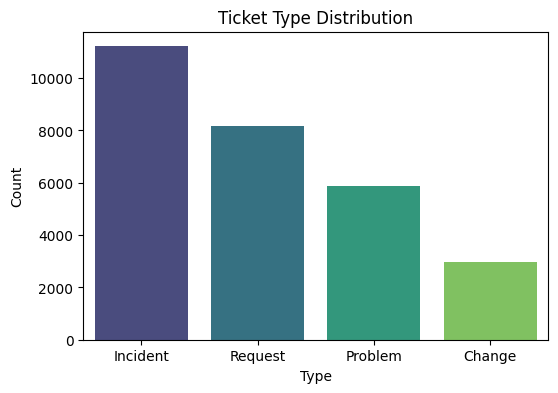

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df3, x='type', order=df3['type'].value_counts().index, palette='viridis')
plt.title("Ticket Type Distribution")
plt.ylabel("Count")
plt.xlabel("Type")
plt.show()

/tmp/ipykernel_70360/1047352555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='type', y='text_length', order=df3['type'].value_counts().index, palette='magma')


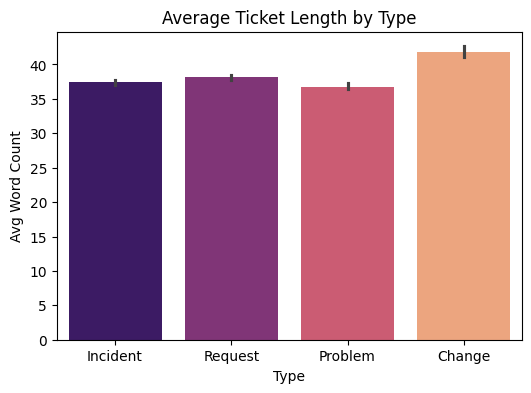

In [39]:
# Average ticket length
df3['text_length'] = df3['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
sns.barplot(data=df3, x='type', y='text_length', order=df3['type'].value_counts().index, palette='magma')
plt.title("Average Ticket Length by Type")
plt.ylabel("Avg Word Count")
plt.xlabel("Type")
plt.show()